In [7]:
import os
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
import oasis.functions
from tqdm import tqdm
import oasis
import pandas as pd

def normalize_crosscorr_0_to_1(C):
    """
    Normalize a 2D cross-correlation matrix to range [0, 1].
    
    Parameters:
        C (numpy.ndarray): Input 2D correlation matrix.
    Returns:
        numpy.ndarray: Normalized correlation matrix (0 to 1).
    """
    # Replace NaN values with 0
    C = np.nan_to_num(C, nan=0.0)
    
    C_min = np.min(C)
    C_max = np.max(C)
    
    # Avoid division by zero if the matrix is constant
    if C_max == C_min:
        return np.zeros_like(C)
    
    # Normalize to [0, 1] range
    C_norm = (C - C_min) / (C_max - C_min)
    return C_norm

def calculate_cross_correlation_multiple_iterations(data, n_iterations=10, subsample_ratio=0.8):
    """
    Calculate cross-correlation matrix across multiple iterations by subsampling the data.
    Handles empty/invalid data gracefully.
    
    Parameters:
        data (numpy.ndarray): Neural activity data with shape (n_cells, n_frames)
        n_iterations (int): Number of iterations for correlation calculation
        subsample_ratio (float): Fraction of data to use in each iteration (0-1)
    
    Returns:
        numpy.ndarray: Mean cross-correlation matrix across iterations
        numpy.ndarray: Standard deviation of cross-correlations across iterations
    """
    n_cells, n_frames = data.shape
    
    print(f"Starting correlation calculation: {n_cells} cells, {n_frames} frames")
    print(f"Will run {n_iterations} iterations with {subsample_ratio*100}% subsampling")
    
    # Check for empty or invalid data
    if n_cells == 0 or n_frames == 0:
        print("Warning: Empty data provided to correlation function")
        return np.zeros((n_cells, n_cells)), np.zeros((n_cells, n_cells))
    
    # Remove cells with all zeros or NaN values - but do this more carefully
    valid_cells = []
    for i in range(n_cells):
        cell_data = data[i, :]
        # Check for valid data: not all zeros, not all NaN, has some variance
        if (not np.all(cell_data == 0) and 
            not np.all(np.isnan(cell_data)) and 
            np.var(cell_data) > 1e-10):  # Very small threshold for variance
            valid_cells.append(i)
        else:
            print(f"Cell {i} excluded: all zeros={np.all(cell_data == 0)}, "
                  f"all NaN={np.all(np.isnan(cell_data))}, var={np.var(cell_data):.2e}")
    
    if len(valid_cells) < 2:
        print(f"Warning: Only {len(valid_cells)} valid cells found. Need at least 2 for correlation.")
        return np.eye(n_cells), np.zeros((n_cells, n_cells))
    
    print(f"Using {len(valid_cells)} out of {n_cells} cells for correlation analysis")
    
    all_correlation_matrices = np.zeros((n_iterations, n_cells, n_cells))
    
    # Add timing check
    import time
    start_time = time.time()
    
    for i in tqdm(range(n_iterations), desc="Calculating correlations"):
        iteration_start = time.time()
        
        try:
            # Randomly subsample frames
            n_subsample = max(int(n_frames * subsample_ratio), 10)  # Ensure minimum frames
            if n_subsample >= n_frames:
                subsample_indices = np.arange(n_frames)
            else:
                subsample_indices = np.random.choice(n_frames, n_subsample, replace=False)
            
            # Debug: Print info for first few iterations
            if i < 3:
                print(f"Iteration {i}: subsampling {n_subsample} out of {n_frames} frames")
            
            # Calculate correlation on subsampled data
            subsampled_data = data[:, subsample_indices]
            
            # Initialize correlation matrix with identity (diagonal = 1)
            correlation_matrix = np.eye(n_cells)
            
            # Calculate correlations only for valid cells
            if len(valid_cells) >= 2:
                valid_data = subsampled_data[valid_cells, :]
                
                # This is the expensive operation - let's time it
                corr_start = time.time()
                valid_corr = np.corrcoef(valid_data)
                corr_time = time.time() - corr_start
                
                if i < 3:
                    print(f"  np.corrcoef took {corr_time:.4f} seconds for {len(valid_cells)} cells")
                
                # Handle single valid cell case
                if valid_corr.ndim == 0:
                    valid_corr = np.array([[1.0]])
                elif valid_corr.ndim == 1:
                    valid_corr = valid_corr.reshape(1, 1)
                
                # Fill in the correlation matrix for valid cells
                for idx_i, cell_i in enumerate(valid_cells):
                    for idx_j, cell_j in enumerate(valid_cells):
                        correlation_matrix[cell_i, cell_j] = valid_corr[idx_i, idx_j]
            
            # Replace NaN values with 0 (except diagonal)
            correlation_matrix = np.nan_to_num(correlation_matrix, nan=0.0)
            np.fill_diagonal(correlation_matrix, 1.0)
            
            all_correlation_matrices[i] = correlation_matrix
            
            iteration_time = time.time() - iteration_start
            if i < 3:
                print(f"Iteration {i} completed in {iteration_time:.4f} seconds")
            
        except Exception as e:
            print(f"Error in iteration {i}: {e}")
            # Use identity matrix for failed iterations
            all_correlation_matrices[i] = np.eye(n_cells)
    
    total_time = time.time() - start_time
    print(f"Total correlation calculation time: {total_time:.2f} seconds")
    print(f"Average time per iteration: {total_time/n_iterations:.4f} seconds")
    
    # Calculate mean and std of correlation matrices
    mean_correlation = np.mean(all_correlation_matrices, axis=0)
    std_correlation = np.std(all_correlation_matrices, axis=0)
    
    return mean_correlation, std_correlation

def process_spike_data_raw(DFF_final, n_cells, numFrames):
    """
    Process spike data WITHOUT any normalization to preserve raw amplitude relationships.
    
    Parameters:
        DFF_final: DFF data array
        n_cells: Number of cells
        numFrames: Number of frames
    
    Returns:
        spikes: Raw processed spike data (NO NORMALIZATION)
    """
    # Initialize arrays
    spikes = np.zeros([n_cells, numFrames])
    norm_spikes = np.zeros([n_cells, numFrames])    
    print("Calculating RAW spikes (no normalization)...")
    successful_cells = 0
    failed_cells = 0
    
    for c in tqdm(range(n_cells)):
        try:
            # Get cell data and check if valid
            cell_dff = DFF_final[c, :].copy()
            
            # Skip if cell has no variation or is all zeros/NaN
            if (np.all(cell_dff == 0) or 
                np.all(np.isnan(cell_dff)) or 
                np.var(cell_dff) < 1e-10 or
                len(cell_dff) == 0):
                print(f"Skipping cell {c}: no valid data (var={np.var(cell_dff):.2e})")
                failed_cells += 1
                continue
            
            # Deconvolved spiking activity
            g = oasis.functions.estimate_time_constant(cell_dff, 1)
            _, cell_spikes = oasis.oasisAR1(cell_dff, g)
            
            # Check if spike detection produced valid results
            if np.all(cell_spikes == 0) or np.all(np.isnan(cell_spikes)):
                print(f"Cell {c}: spike detection failed, using zeros")
                failed_cells += 1
                continue
            
            # # NO NORMALIZATION - use raw spike amplitudes
            spikes[c, :] = cell_spikes
            successful_cells += 1
            
            # Normalize spikes
            spikes_min = np.min(spikes[c])
            spikes_max = np.max(spikes[c])
            if spikes_max > spikes_min:  # Avoid division by zero
                norm_spikes[c] = (spikes[c] - spikes_min) / (spikes_max - spikes_min)
                
        except Exception as e:
            print(f"Error processing cell {c}: {e}")
            failed_cells += 1
            # Keep zeros for failed cells
            continue
    
    print(f"RAW spike processing complete: {successful_cells} successful, {failed_cells} failed")
    return spikes, norm_spikes



Processing folder: B1_WS259.2_D90_org1-002
Loading .mat file: B1_data.mat
Data type: [('filename', 'O'), ('numFrames', 'O'), ('xPixels', 'O'), ('yPixels', 'O'), ('map_type', 'O'), ('frameRate', 'O'), ('avg_projection', 'O'), ('frame_F', 'O'), ('activity_map', 'O'), ('cellMasks', 'O'), ('raw_F', 'O'), ('normtype', 'O'), ('neuropil_F', 'O'), ('r_neuropil', 'O'), ('DFF_raw', 'O'), ('DFF', 'O')]
  Filename: B1.tif
  Number of frames: 4507
  Frame rate: 15.023206948701938
  Number of cells detected: 424
DFF shape: (424, 4507)
DFF range: -87.0358 to 291.9157
DFF has NaN: False
Calculating RAW spikes (no normalization)...


  0%|          | 0/424 [00:00<?, ?it/s]c:\Users\jasmineyeo\AppData\Local\anaconda3\envs\JSY_SpatialMod\Lib\site-packages\oasis\functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],
C:\Users\jasmineyeo\AppData\Local\Temp\ipykernel_44080\1386533739.py:186: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  _, cell_spikes = oasis.oasisAR1(cell_dff, g)
100%|██████████| 424/424 [00:00<00:00, 2070.06it/s]


RAW spike processing complete: 424 successful, 0 failed
Raw spikes shape: (424, 4507)
Raw spikes range: 0.0000 to 212.3969
Non-zero spikes in 424 out of 424 cells
=== CORRELATION ANALYSIS COMPARISON ===
Cells 0-1: DFF corr=0.024, Raw Spike corr=0.036
Cells 0-2: DFF corr=-0.003, Raw Spike corr=0.011
Cells 1-2: DFF corr=0.040, Raw Spike corr=0.020
Cells 1-3: DFF corr=0.020, Raw Spike corr=0.019
Cells 2-3: DFF corr=0.019, Raw Spike corr=0.000
Cells 2-4: DFF corr=0.034, Raw Spike corr=0.028
Cells 3-4: DFF corr=0.036, Raw Spike corr=0.041
Cells 3-5: DFF corr=0.027, Raw Spike corr=0.002
Cells 4-5: DFF corr=0.055, Raw Spike corr=0.006
Cells 4-6: DFF corr=0.066, Raw Spike corr=0.057
DFF mean activity per cell: 4.26
Raw spike mean activity per cell: 0.50
DFF active frames per cell: 2471.8
Raw spike active frames per cell: 248.2
Plotting raw spike data...


KeyboardInterrupt: 

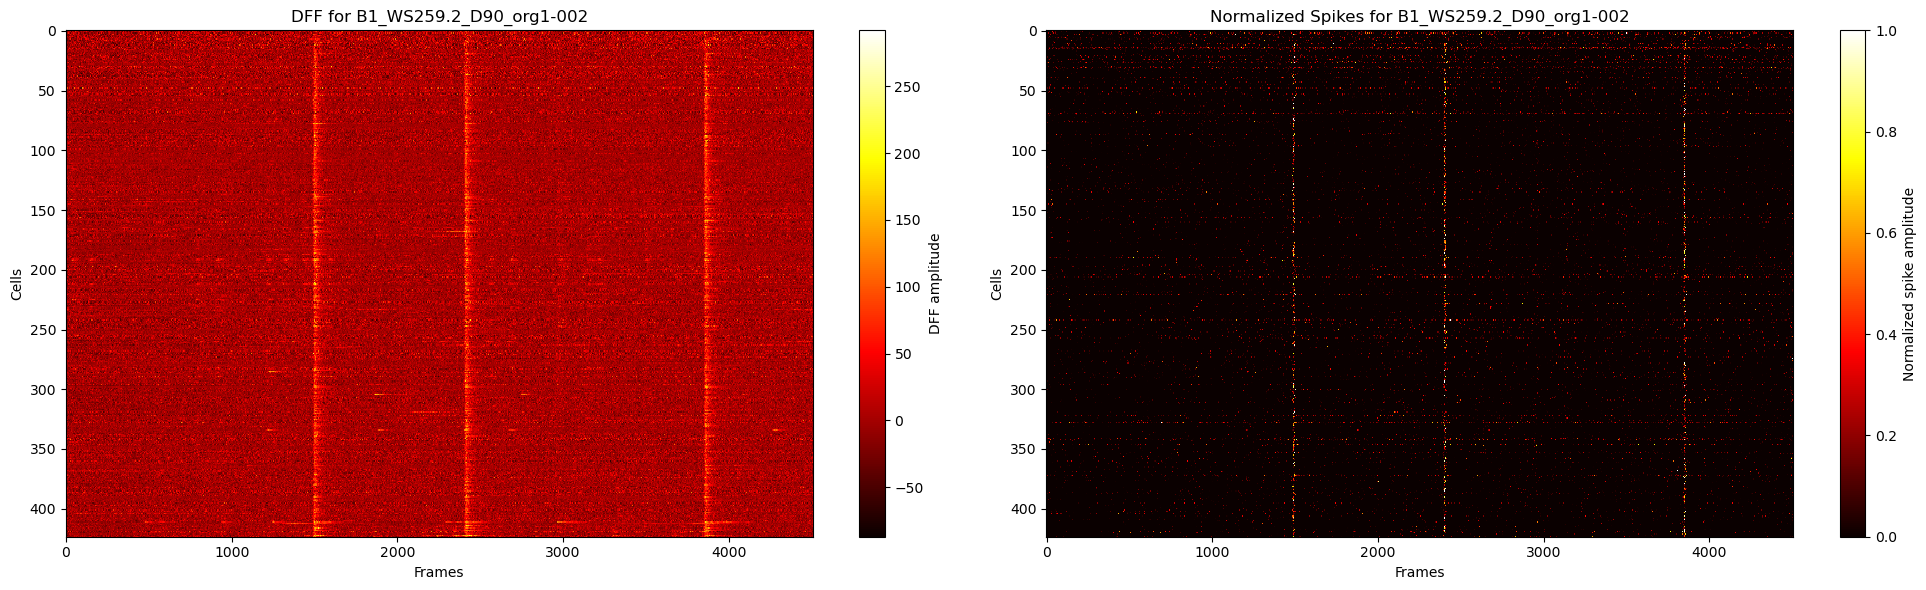

In [8]:
# Find the number of subfolders in the folder
folder_path = r'F:\inyoung\250605\New folder'
subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir()]
num_subfolders = len(subfolders)

# Set parameters for correlation calculation
n_iterations = 1000  # Number of iterations
subsample_ratio = 0.9  # Use 90% of frames in each iteration

# Loop through the subfolders
for subfolder in subfolders:
    try:
        # Get the base path and record name
        basepath = subfolder
        rec_name = os.path.basename(subfolder)
        print(f"Processing folder: {rec_name}")
        
        # Find all .mat files in the subfolder
        mat_files = [f for f in os.listdir(basepath) if f.endswith('.mat')]
        
        if not mat_files:
            print(f"No .mat files found in {rec_name}")
            continue
            
        for mat_file in mat_files:
            try:
                mat_file_path = os.path.join(basepath, mat_file)
                print(f"Loading .mat file: {mat_file}")
                
                # Load the .mat file
                mat_data = sio.loadmat(mat_file_path)
                
                # Extract the 'data' field
                if 'data' not in mat_data:
                    print("No 'data' field found in this .mat file")
                    continue
                    
                data_struct = mat_data['data']
                print(f"Data type: {data_struct.dtype}")
                
                # Extract each field from the structure
                data_fields = {}
                for field_name in data_struct.dtype.names:
                    data_fields[field_name] = data_struct[0, 0][field_name]
                
                # Extract fields of interest
                filename = data_fields['filename']
                numFrames = data_fields['numFrames'][0][0] if data_fields['numFrames'].size > 0 else 0
                frameRate = data_fields['frameRate'][0][0] if data_fields['frameRate'].size > 0 else 0
                cellMasks = data_fields['cellMasks']
                DFF_final = data_fields['DFF']
                
                # Print summary information
                print(f"  Filename: {filename[0] if filename.size > 0 else 'Empty'}")
                print(f"  Number of frames: {numFrames}")
                print(f"  Frame rate: {frameRate}")
                n_cells = cellMasks.shape[1] if hasattr(cellMasks, 'shape') else 0
                print(f"  Number of cells detected: {n_cells}")
                
                if n_cells == 0 or numFrames == 0:
                    print("No cells or frames detected, skipping this file")
                    continue
                
                # Validate DFF data
                print(f"DFF shape: {DFF_final.shape}")
                print(f"DFF range: {np.min(DFF_final):.4f} to {np.max(DFF_final):.4f}")
                print(f"DFF has NaN: {np.any(np.isnan(DFF_final))}")
                
                # Calculate RAW spikes (no normalization)
                raw_spikes, norm_spikes = process_spike_data_raw(DFF_final, n_cells, numFrames)
                
                # Validate spike data
                print(f"Raw spikes shape: {raw_spikes.shape}")
                print(f"Raw spikes range: {np.min(raw_spikes):.4f} to {np.max(raw_spikes):.4f}")
                print(f"Non-zero spikes in {np.sum(np.any(raw_spikes > 0, axis=1))} out of {n_cells} cells")
                
                # Add correlation comparison diagnostics
                print("=== CORRELATION ANALYSIS COMPARISON ===")
                
                # Sample a few cell pairs to see the difference
                for i in range(0, min(5, n_cells-1)):
                    for j in range(i+1, min(i+3, n_cells)):
                        dff_corr = np.corrcoef(DFF_final[i,:], DFF_final[j,:])[0,1]
                        spike_corr = np.corrcoef(raw_spikes[i,:], raw_spikes[j,:])[0,1]
                        print(f"Cells {i}-{j}: DFF corr={dff_corr:.3f}, Raw Spike corr={spike_corr:.3f}")
                
                # Check temporal structure
                print(f"DFF mean activity per cell: {np.mean(np.mean(DFF_final, axis=1)):.2f}")
                print(f"Raw spike mean activity per cell: {np.mean(np.mean(raw_spikes, axis=1)):.2f}")
                print(f"DFF active frames per cell: {np.mean(np.sum(DFF_final > 0, axis=1)):.1f}")
                print(f"Raw spike active frames per cell: {np.mean(np.sum(raw_spikes > 0, axis=1)):.1f}")
                
                # Save the processed data
                twop_dict = {
                    'filename': filename,
                    'numFrames': numFrames,
                    'frameRate': frameRate,
                    'cellMasks': cellMasks,
                    'DFF_final': DFF_final,
                    'raw_spikes': raw_spikes,
                    'norm_spikes': norm_spikes
                }
                
                # Plot raw spikes
                print("Plotting raw spike data...")
                fig, axs = plt.subplots(1, 2, figsize=(20, 6))
                
                im0 = axs[0].imshow(DFF_final, aspect='auto', cmap='hot', interpolation='nearest')
                axs[0].set_title(f'DFF for {rec_name}')
                axs[0].set_xlabel('Frames')
                axs[0].set_ylabel('Cells')
                fig.colorbar(im0, ax=axs[0], label='DFF amplitude')
                
                im1 = axs[1].imshow(norm_spikes, aspect='auto', cmap='hot', interpolation='nearest')
                axs[1].set_title(f'Normalized Spikes for {rec_name}')
                axs[1].set_xlabel('Frames')
                axs[1].set_ylabel('Cells')
                fig.colorbar(im1, ax=axs[1], label='Normalized spike amplitude')
                
                plt.tight_layout()
                spike_fig_path = os.path.join(basepath, f"{rec_name}_DFFandNormSpikes.jpg")
                plt.savefig(spike_fig_path, dpi=300)
                plt.close()
                print(f"Saved norm spike plot to {spike_fig_path}")
                
                # Calculate cross-correlation with multiple iterations
                print(f"Calculating cross-correlations across {n_iterations} iterations...")
                mean_corr_dff, std_corr_dff = calculate_cross_correlation_multiple_iterations(
                    DFF_final, n_iterations=n_iterations, subsample_ratio=subsample_ratio
                )
                
                mean_corr_norm_spikes, std_corr_norm_spikes = calculate_cross_correlation_multiple_iterations(
                    norm_spikes, n_iterations=n_iterations, subsample_ratio=subsample_ratio
                )
                
                # Use 0-1 normalization
                norm_corr_dff = normalize_crosscorr_0_to_1(mean_corr_dff)
                norm_corr_norm_spikes = normalize_crosscorr_0_to_1(mean_corr_norm_spikes)
                
                # Plot the cross-correlation matrices with red-blue colormap
                plt.figure(figsize=(14, 6))
                
                plt.subplot(1, 2, 1)
                im1 = plt.imshow(norm_corr_dff, aspect='auto', cmap='RdBu_r', interpolation='nearest', vmin=0, vmax=1)
                plt.colorbar(im1, label='Cross-correlation (DFF)')
                plt.title(f'Mean Cross-correlation (DFF)\n{n_iterations} iterations')
                plt.xlabel('Cells')
                plt.ylabel('Cells')
                
                plt.subplot(1, 2, 2)
                im2 = plt.imshow(norm_corr_norm_spikes, aspect='auto', cmap='RdBu_r', interpolation='nearest', vmin=0, vmax=1)
                plt.colorbar(im2, label='Cross-correlation (Normalized Spikes)')
                plt.title(f'Mean Cross-correlation (Normalized Spikes)\n{n_iterations} iterations')
                plt.xlabel('Cells')
                plt.ylabel('Cells')
                
                plt.tight_layout()
                corr_fig_path = os.path.join(basepath, f"{rec_name}_Normalized_spikes_cross_correlation_{n_iterations}iter.jpg")
                plt.savefig(corr_fig_path, dpi=300)
                plt.close()
                print(f"Saved correlation plot to {corr_fig_path}")
                
                # Save the correlation matrices
                corr_dict = {
                    'mean_corr_dff': mean_corr_dff,
                    'std_corr_dff': std_corr_dff,
                    'mean_corr_raw_spikes': mean_corr_norm_spikes,
                    'std_corr_raw_spikes': std_corr_norm_spikes,
                    'norm_corr_dff': norm_corr_dff,
                    'norm_corr_raw_spikes': norm_corr_norm_spikes,
                    'n_iterations': n_iterations,
                    'subsample_ratio': subsample_ratio
                }
                
                npy_filename = os.path.splitext(mat_file)[0] + f'_Normalized_spikes_correlations_{n_iterations}iter.npy'
                npy_file_path = os.path.join(basepath, npy_filename)
                np.save(npy_file_path, corr_dict)
                print(f"Saved correlation data to {npy_filename}")
                
                csv_filename = os.path.splitext(mat_file)[0] + f'_Normalized_spikes_correlations_{n_iterations}iter.csv'
                csv_file_path = os.path.join(basepath, csv_filename)
                pd.DataFrame(norm_corr_dff).to_csv(csv_file_path, index=False)
                print(f"Saved correlation data to {csv_filename}")
                
            except Exception as e:
                print(f"Error processing file {mat_file}: {e}")
                import traceback
                traceback.print_exc()
    
    except Exception as e:
        print(f"Error processing folder {subfolder}: {e}")
        import traceback
        traceback.print_exc()

print("Normalized spikes processing complete!")

In [12]:
import os
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
import oasis.functions
from tqdm import tqdm
import oasis
import pandas as pd

# REMOVED THE MISLEADING normalize_crosscorr_0_to_1 FUNCTION

def calculate_cross_correlation_multiple_iterations(data, n_iterations=10, subsample_ratio=0.8):
    """
    Calculate cross-correlation matrix across multiple iterations by subsampling the data.
    Handles empty/invalid data gracefully.
    
    Parameters:
        data (numpy.ndarray): Neural activity data with shape (n_cells, n_frames)
        n_iterations (int): Number of iterations for correlation calculation
        subsample_ratio (float): Fraction of data to use in each iteration (0-1)
    
    Returns:
        numpy.ndarray: Mean cross-correlation matrix across iterations
        numpy.ndarray: Standard deviation of cross-correlations across iterations
    """
    n_cells, n_frames = data.shape
    
    print(f"Starting correlation calculation: {n_cells} cells, {n_frames} frames")
    print(f"Will run {n_iterations} iterations with {subsample_ratio*100}% subsampling")
    
    # Check for empty or invalid data
    if n_cells == 0 or n_frames == 0:
        print("Warning: Empty data provided to correlation function")
        return np.zeros((n_cells, n_cells)), np.zeros((n_cells, n_cells))
    
    # Remove cells with all zeros or NaN values - but do this more carefully
    valid_cells = []
    for i in range(n_cells):
        cell_data = data[i, :]
        # Check for valid data: not all zeros, not all NaN, has some variance
        if (not np.all(cell_data == 0) and 
            not np.all(np.isnan(cell_data)) and 
            np.var(cell_data) > 1e-10):  # Very small threshold for variance
            valid_cells.append(i)
        else:
            print(f"Cell {i} excluded: all zeros={np.all(cell_data == 0)}, "
                  f"all NaN={np.all(np.isnan(cell_data))}, var={np.var(cell_data):.2e}")
    
    if len(valid_cells) < 2:
        print(f"Warning: Only {len(valid_cells)} valid cells found. Need at least 2 for correlation.")
        return np.eye(n_cells), np.zeros((n_cells, n_cells))
    
    print(f"Using {len(valid_cells)} out of {n_cells} cells for correlation analysis")
    
    all_correlation_matrices = np.zeros((n_iterations, n_cells, n_cells))
    
    # Add timing check
    import time
    start_time = time.time()
    
    for i in tqdm(range(n_iterations), desc="Calculating correlations"):
        iteration_start = time.time()
        
        try:
            # Randomly subsample frames
            n_subsample = max(int(n_frames * subsample_ratio), 10)  # Ensure minimum frames
            if n_subsample >= n_frames:
                subsample_indices = np.arange(n_frames)
            else:
                subsample_indices = np.random.choice(n_frames, n_subsample, replace=False)
            
            # Debug: Print info for first few iterations
            if i < 3:
                print(f"Iteration {i}: subsampling {n_subsample} out of {n_frames} frames")
            
            # Calculate correlation on subsampled data
            subsampled_data = data[:, subsample_indices]
            
            # Initialize correlation matrix with identity (diagonal = 1)
            correlation_matrix = np.eye(n_cells)
            
            # Calculate correlations only for valid cells
            if len(valid_cells) >= 2:
                valid_data = subsampled_data[valid_cells, :]
                
                # This is the expensive operation - let's time it
                corr_start = time.time()
                valid_corr = np.corrcoef(valid_data)
                corr_time = time.time() - corr_start
                
                if i < 3:
                    print(f"  np.corrcoef took {corr_time:.4f} seconds for {len(valid_cells)} cells")
                
                # Handle single valid cell case
                if valid_corr.ndim == 0:
                    valid_corr = np.array([[1.0]])
                elif valid_corr.ndim == 1:
                    valid_corr = valid_corr.reshape(1, 1)
                
                # Fill in the correlation matrix for valid cells
                for idx_i, cell_i in enumerate(valid_cells):
                    for idx_j, cell_j in enumerate(valid_cells):
                        correlation_matrix[cell_i, cell_j] = valid_corr[idx_i, idx_j]
            
            # Replace NaN values with 0 (except diagonal)
            correlation_matrix = np.nan_to_num(correlation_matrix, nan=0.0)
            np.fill_diagonal(correlation_matrix, 1.0)
            
            all_correlation_matrices[i] = correlation_matrix
            
            iteration_time = time.time() - iteration_start
            if i < 3:
                print(f"Iteration {i} completed in {iteration_time:.4f} seconds")
            
        except Exception as e:
            print(f"Error in iteration {i}: {e}")
            # Use identity matrix for failed iterations
            all_correlation_matrices[i] = np.eye(n_cells)
    
    total_time = time.time() - start_time
    print(f"Total correlation calculation time: {total_time:.2f} seconds")
    print(f"Average time per iteration: {total_time/n_iterations:.4f} seconds")
    
    # Calculate mean and std of correlation matrices
    mean_correlation = np.mean(all_correlation_matrices, axis=0)
    std_correlation = np.std(all_correlation_matrices, axis=0)
    
    return mean_correlation, std_correlation

def process_spike_data_raw(DFF_final, n_cells, numFrames):
    """
    Process spike data WITHOUT any normalization to preserve raw amplitude relationships.
    
    Parameters:
        DFF_final: DFF data array
        n_cells: Number of cells
        numFrames: Number of frames
    
    Returns:
        spikes: Raw processed spike data (NO NORMALIZATION)
    """
    # Initialize arrays
    spikes = np.zeros([n_cells, numFrames])
    norm_spikes = np.zeros([n_cells, numFrames])    
    print("Calculating RAW spikes (no normalization)...")
    successful_cells = 0
    failed_cells = 0
    
    for c in tqdm(range(n_cells)):
        try:
            # Get cell data and check if valid
            cell_dff = DFF_final[c, :].copy()
            
            # Skip if cell has no variation or is all zeros/NaN
            if (np.all(cell_dff == 0) or 
                np.all(np.isnan(cell_dff)) or 
                np.var(cell_dff) < 1e-10 or
                len(cell_dff) == 0):
                print(f"Skipping cell {c}: no valid data (var={np.var(cell_dff):.2e})")
                failed_cells += 1
                continue
            
            # Deconvolved spiking activity
            g = oasis.functions.estimate_time_constant(cell_dff, 1)
            _, cell_spikes = oasis.oasisAR1(cell_dff, g)
            
            # Check if spike detection produced valid results
            if np.all(cell_spikes == 0) or np.all(np.isnan(cell_spikes)):
                print(f"Cell {c}: spike detection failed, using zeros")
                failed_cells += 1
                continue
            
            # # NO NORMALIZATION - use raw spike amplitudes
            spikes[c, :] = cell_spikes
            successful_cells += 1
            
            # Normalize spikes
            spikes_min = np.min(spikes[c])
            spikes_max = np.max(spikes[c])
            if spikes_max > spikes_min:  # Avoid division by zero
                norm_spikes[c] = (spikes[c] - spikes_min) / (spikes_max - spikes_min)
                
        except Exception as e:
            print(f"Error processing cell {c}: {e}")
            failed_cells += 1
            # Keep zeros for failed cells
            continue
    
    print(f"RAW spike processing complete: {successful_cells} successful, {failed_cells} failed")
    return spikes, norm_spikes

def print_correlation_statistics(mean_corr_dff, mean_corr_spikes, rec_name):
    """
    Print detailed correlation statistics without misleading normalization.
    """
    print(f"\n=== CORRELATION STATISTICS FOR {rec_name} ===")
    
    # DFF correlations (excluding diagonal)
    dff_corr_values = mean_corr_dff[np.triu_indices_from(mean_corr_dff, k=1)]
    print(f"DFF correlations - Min: {np.min(dff_corr_values):.3f}, Max: {np.max(dff_corr_values):.3f}, Mean: {np.mean(dff_corr_values):.3f}")
    
    # Spike correlations (excluding diagonal)  
    spike_corr_values = mean_corr_spikes[np.triu_indices_from(mean_corr_spikes, k=1)]
    print(f"Spike correlations - Min: {np.min(spike_corr_values):.3f}, Max: {np.max(spike_corr_values):.3f}, Mean: {np.mean(spike_corr_values):.3f}")
    
    # Calculate correlation difference
    corr_diff = abs(np.mean(dff_corr_values) - np.mean(spike_corr_values))
    print(f"Mean correlation difference: {corr_diff:.3f}")
    
    return np.mean(dff_corr_values), np.mean(spike_corr_values)

# MAIN PROCESSING LOOP - FIXED VERSION
# Find the number of subfolders in the folder
folder_path = r'F:\inyoung\250605\New folder'
subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir()]
num_subfolders = len(subfolders)

# Set parameters for correlation calculation
n_iterations = 1000  # Number of iterations
subsample_ratio = 0.1  # Use 90% of frames in each iteration

# Loop through the subfolders
for subfolder in subfolders:
    try:
        # Get the base path and record name
        basepath = subfolder
        rec_name = os.path.basename(subfolder)
        print(f"Processing folder: {rec_name}")
        
        # Find all .mat files in the subfolder
        mat_files = [f for f in os.listdir(basepath) if f.endswith('.mat')]
        
        if not mat_files:
            print(f"No .mat files found in {rec_name}")
            continue
            
        for mat_file in mat_files:
            try:
                mat_file_path = os.path.join(basepath, mat_file)
                print(f"Loading .mat file: {mat_file}")
                
                # Load the .mat file
                mat_data = sio.loadmat(mat_file_path)
                
                # Extract the 'data' field
                if 'data' not in mat_data:
                    print("No 'data' field found in this .mat file")
                    continue
                    
                data_struct = mat_data['data']
                print(f"Data type: {data_struct.dtype}")
                
                # Extract each field from the structure
                data_fields = {}
                for field_name in data_struct.dtype.names:
                    data_fields[field_name] = data_struct[0, 0][field_name]
                
                # Extract fields of interest
                filename = data_fields['filename']
                numFrames = data_fields['numFrames'][0][0] if data_fields['numFrames'].size > 0 else 0
                frameRate = data_fields['frameRate'][0][0] if data_fields['frameRate'].size > 0 else 0
                cellMasks = data_fields['cellMasks']
                DFF_final = data_fields['DFF']
                
                # Print summary information
                print(f"  Filename: {filename[0] if filename.size > 0 else 'Empty'}")
                print(f"  Number of frames: {numFrames}")
                print(f"  Frame rate: {frameRate}")
                n_cells = cellMasks.shape[1] if hasattr(cellMasks, 'shape') else 0
                print(f"  Number of cells detected: {n_cells}")
                
                if n_cells == 0 or numFrames == 0:
                    print("No cells or frames detected, skipping this file")
                    continue
                
                # Validate DFF data
                print(f"DFF shape: {DFF_final.shape}")
                print(f"DFF range: {np.min(DFF_final):.4f} to {np.max(DFF_final):.4f}")
                print(f"DFF has NaN: {np.any(np.isnan(DFF_final))}")
                
                # Calculate RAW spikes (no normalization)
                raw_spikes, norm_spikes = process_spike_data_raw(DFF_final, n_cells, numFrames)
                
                # Validate spike data
                print(f"Raw spikes shape: {raw_spikes.shape}")
                print(f"Raw spikes range: {np.min(raw_spikes):.4f} to {np.max(raw_spikes):.4f}")
                print(f"Non-zero spikes in {np.sum(np.any(raw_spikes > 0, axis=1))} out of {n_cells} cells")
                
                # Add correlation comparison diagnostics
                print("=== CORRELATION ANALYSIS COMPARISON ===")
                
                # Sample a few cell pairs to see the difference
                for i in range(0, min(5, n_cells-1)):
                    for j in range(i+1, min(i+3, n_cells)):
                        dff_corr = np.corrcoef(DFF_final[i,:], DFF_final[j,:])[0,1]
                        spike_corr = np.corrcoef(raw_spikes[i,:], raw_spikes[j,:])[0,1]
                        print(f"Cells {i}-{j}: DFF corr={dff_corr:.3f}, Raw Spike corr={spike_corr:.3f}")
                
                # Check temporal structure
                print(f"DFF mean activity per cell: {np.mean(np.mean(DFF_final, axis=1)):.2f}")
                print(f"Raw spike mean activity per cell: {np.mean(np.mean(raw_spikes, axis=1)):.2f}")
                print(f"DFF active frames per cell: {np.mean(np.sum(DFF_final > 0, axis=1)):.1f}")
                print(f"Raw spike active frames per cell: {np.mean(np.sum(raw_spikes > 0, axis=1)):.1f}")
                
                # Save the processed data
                twop_dict = {
                    'filename': filename,
                    'numFrames': numFrames,
                    'frameRate': frameRate,
                    'cellMasks': cellMasks,
                    'DFF_final': DFF_final,
                    'raw_spikes': raw_spikes,
                    'norm_spikes': norm_spikes
                }
                
                # Plot raw spikes
                print("Plotting raw spike data...")
                fig, axs = plt.subplots(1, 2, figsize=(20, 6))
                
                im0 = axs[0].imshow(DFF_final, aspect='auto', cmap='hot', interpolation='nearest')
                axs[0].set_title(f'DFF for {rec_name}')
                axs[0].set_xlabel('Frames')
                axs[0].set_ylabel('Cells')
                fig.colorbar(im0, ax=axs[0], label='DFF amplitude')
                
                im1 = axs[1].imshow(norm_spikes, aspect='auto', cmap='hot', interpolation='nearest')
                axs[1].set_title(f'Normalized Spikes for {rec_name}')
                axs[1].set_xlabel('Frames')
                axs[1].set_ylabel('Cells')
                fig.colorbar(im1, ax=axs[1], label='Normalized spike amplitude')
                
                plt.tight_layout()
                spike_fig_path = os.path.join(basepath, f"{rec_name}_savefigDFFandNormSpikes.jpg")
                plt.savefig(spike_fig_path, dpi=300)
                plt.close()
                print(f"Saved norm spike plot to {spike_fig_path}")
                
                # Calculate cross-correlation with multiple iterations
                print(f"Calculating cross-correlations across {n_iterations} iterations...")
                mean_corr_dff, std_corr_dff = calculate_cross_correlation_multiple_iterations(
                    DFF_final, n_iterations=n_iterations, subsample_ratio=subsample_ratio
                )
                
                mean_corr_norm_spikes, std_corr_norm_spikes = calculate_cross_correlation_multiple_iterations(
                    norm_spikes, n_iterations=n_iterations, subsample_ratio=subsample_ratio
                )
                
                # FIXED: Print correlation statistics WITHOUT misleading normalization
                mean_dff_corr, mean_spike_corr = print_correlation_statistics(
                    mean_corr_dff, mean_corr_norm_spikes, rec_name
                )
                
                # FIXED: Plot with RAW correlation values using consistent color scale
                plt.figure(figsize=(14, 6))
                
                # Use consistent color scale for fair comparison: -0.2 to 1.0
                vmin, vmax = 0, 1.0
                
                plt.subplot(1, 2, 1)
                im1 = plt.imshow(mean_corr_dff, aspect='auto', cmap='RdBu_r', 
                               interpolation='nearest', vmin=vmin, vmax=vmax)
                plt.colorbar(im1, label='Correlation Coefficient')
                plt.title(f'DFF Correlations - {rec_name}\nMean: {mean_dff_corr:.3f}')
                plt.xlabel('Cells')
                plt.ylabel('Cells')
                
                plt.subplot(1, 2, 2)
                im2 = plt.imshow(mean_corr_norm_spikes, aspect='auto', cmap='RdBu_r', 
                               interpolation='nearest', vmin=vmin, vmax=vmax)
                plt.colorbar(im2, label='Correlation Coefficient')
                plt.title(f'Spike Correlations - {rec_name}\nMean: {mean_spike_corr:.3f}')
                plt.xlabel('Cells')
                plt.ylabel('Cells')
                
                plt.tight_layout()
                corr_fig_path = os.path.join(basepath, f"{rec_name}_0.1subsamplecorrelations_{n_iterations}iter.jpg")
                plt.savefig(corr_fig_path, dpi=300)
                plt.close()
                print(f"Saved correlation plot to {corr_fig_path}")
                
                # Save the correlation matrices with RAW values
                corr_dict = {
                    'mean_corr_dff': mean_corr_dff,
                    'std_corr_dff': std_corr_dff,
                    'mean_corr_norm_spikes': mean_corr_norm_spikes,
                    'std_corr_norm_spikes': std_corr_norm_spikes,
                    'mean_dff_correlation': mean_dff_corr,
                    'mean_spike_correlation': mean_spike_corr,
                    'n_iterations': n_iterations,
                    'subsample_ratio': subsample_ratio
                }
                
                # npy_filename = os.path.splitext(mat_file)[0] + f'_correlations_{n_iterations}iter.npy'
                # npy_file_path = os.path.join(basepath, npy_filename)
                # np.save(npy_file_path, corr_dict)
                # print(f"Saved correlation data to {npy_filename}")
                
                # csv_filename = os.path.splitext(mat_file)[0] + f'_correlations_{n_iterations}iter.csv'
                # csv_file_path = os.path.join(basepath, csv_filename)
                # pd.DataFrame(mean_corr_dff).to_csv(csv_file_path, index=False)
                # print(f"Saved correlation data to {csv_filename}")
                
            except Exception as e:
                print(f"Error processing file {mat_file}: {e}")
                import traceback
                traceback.print_exc()
    
    except Exception as e:
        print(f"Error processing folder {subfolder}: {e}")
        import traceback
        traceback.print_exc()

print("Correlation processing complete!")

Processing folder: B1_WS259.2_D90_org1-002
Loading .mat file: B1_data.mat
Data type: [('filename', 'O'), ('numFrames', 'O'), ('xPixels', 'O'), ('yPixels', 'O'), ('map_type', 'O'), ('frameRate', 'O'), ('avg_projection', 'O'), ('frame_F', 'O'), ('activity_map', 'O'), ('cellMasks', 'O'), ('raw_F', 'O'), ('normtype', 'O'), ('neuropil_F', 'O'), ('r_neuropil', 'O'), ('DFF_raw', 'O'), ('DFF', 'O')]
  Filename: B1.tif
  Number of frames: 4507
  Frame rate: 15.023206948701938
  Number of cells detected: 424
DFF shape: (424, 4507)
DFF range: -87.0358 to 291.9157
DFF has NaN: False
Calculating RAW spikes (no normalization)...


  0%|          | 0/424 [00:00<?, ?it/s]c:\Users\jasmineyeo\AppData\Local\anaconda3\envs\JSY_SpatialMod\Lib\site-packages\oasis\functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],
C:\Users\jasmineyeo\AppData\Local\Temp\ipykernel_44080\913395719.py:165: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  _, cell_spikes = oasis.oasisAR1(cell_dff, g)
100%|██████████| 424/424 [00:00<00:00, 2081.32it/s]


RAW spike processing complete: 424 successful, 0 failed
Raw spikes shape: (424, 4507)
Raw spikes range: 0.0000 to 212.3969
Non-zero spikes in 424 out of 424 cells
=== CORRELATION ANALYSIS COMPARISON ===
Cells 0-1: DFF corr=0.024, Raw Spike corr=0.036
Cells 0-2: DFF corr=-0.003, Raw Spike corr=0.011
Cells 1-2: DFF corr=0.040, Raw Spike corr=0.020
Cells 1-3: DFF corr=0.020, Raw Spike corr=0.019
Cells 2-3: DFF corr=0.019, Raw Spike corr=0.000
Cells 2-4: DFF corr=0.034, Raw Spike corr=0.028
Cells 3-4: DFF corr=0.036, Raw Spike corr=0.041
Cells 3-5: DFF corr=0.027, Raw Spike corr=0.002
Cells 4-5: DFF corr=0.055, Raw Spike corr=0.006
Cells 4-6: DFF corr=0.066, Raw Spike corr=0.057
DFF mean activity per cell: 4.26
Raw spike mean activity per cell: 0.50
DFF active frames per cell: 2471.8
Raw spike active frames per cell: 247.7
Plotting raw spike data...
Saved norm spike plot to F:\inyoung\250605\New folder\B1_WS259.2_D90_org1-002\B1_WS259.2_D90_org1-002_savefigDFFandNormSpikes.jpg
Calculating 

Calculating correlations:   0%|          | 4/1000 [00:00<00:26, 37.77it/s]

Iteration 0: subsampling 450 out of 4507 frames
  np.corrcoef took 0.0020 seconds for 424 cells
Iteration 0 completed in 0.0268 seconds
Iteration 1: subsampling 450 out of 4507 frames
  np.corrcoef took 0.0019 seconds for 424 cells
Iteration 1 completed in 0.0264 seconds
Iteration 2: subsampling 450 out of 4507 frames
  np.corrcoef took 0.0019 seconds for 424 cells
Iteration 2 completed in 0.0261 seconds


...

Calculating correlations:   0%|          | 0/1000 [00:00<?, ?it/s]c:\Users\jasmineyeo\AppData\Local\anaconda3\envs\JSY_SpatialMod\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\jasmineyeo\AppData\Local\anaconda3\envs\JSY_SpatialMod\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
Calculating correlations:   0%|          | 3/1000 [00:00<00:39, 25.26it/s]

Iteration 0: subsampling 450 out of 4507 frames
  np.corrcoef took 0.0027 seconds for 511 cells
Iteration 0 completed in 0.0400 seconds
Iteration 1: subsampling 450 out of 4507 frames
  np.corrcoef took 0.0024 seconds for 511 cells
Iteration 1 completed in 0.0389 seconds
Iteration 2: subsampling 450 out of 4507 frames
  np.corrcoef took 0.0026 seconds for 511 cells
Iteration 2 completed in 0.0398 seconds


Calculating correlations: 100%|██████████| 1000/1000 [00:40<00:00, 24.78it/s]


Total correlation calculation time: 40.35 seconds
Average time per iteration: 0.0404 seconds

=== CORRELATION STATISTICS FOR B1_WS259.2_D90_org3-002 ===
DFF correlations - Min: -0.360, Max: 0.901, Mean: 0.289
Spike correlations - Min: -0.036, Max: 0.647, Mean: 0.112
Mean correlation difference: 0.177
Saved correlation plot to F:\inyoung\250605\New folder\B1_WS259.2_D90_org3-002\B1_WS259.2_D90_org3-002_0.1subsamplecorrelations_1000iter.jpg
Processing folder: batch1_WS259.2_d120_org2-002
Loading .mat file: batch1_data.mat
Data type: [('filename', 'O'), ('numFrames', 'O'), ('xPixels', 'O'), ('yPixels', 'O'), ('map_type', 'O'), ('frameRate', 'O'), ('avg_projection', 'O'), ('frame_F', 'O'), ('activity_map', 'O')]
Error processing file batch1_data.mat: 'cellMasks'
Processing folder: batch1_WS259.2_d120_org3-002
Loading .mat file: batch1_data.mat
Data type: [('filename', 'O'), ('numFrames', 'O'), ('xPixels', 'O'), ('yPixels', 'O'), ('map_type', 'O'), ('frameRate', 'O'), ('avg_projection', 'O'

Traceback (most recent call last):
  File "C:\Users\jasmineyeo\AppData\Local\Temp\ipykernel_44080\913395719.py", line 262, in <module>
    cellMasks = data_fields['cellMasks']
                ~~~~~~~~~~~^^^^^^^^^^^^^
KeyError: 'cellMasks'
Traceback (most recent call last):
  File "C:\Users\jasmineyeo\AppData\Local\Temp\ipykernel_44080\913395719.py", line 262, in <module>
    cellMasks = data_fields['cellMasks']
                ~~~~~~~~~~~^^^^^^^^^^^^^
KeyError: 'cellMasks'


**Event-Based Correlation Analysis**

In [16]:
import os
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
import oasis.functions
from tqdm import tqdm
import oasis
import pandas as pd

def threshold_based_events(data, method='percentile', threshold=80, min_duration=2):
    """
    Define active periods using threshold-based event detection.
    
    Parameters:
        data: 1D array of calcium signal
        method: 'percentile', 'std', 'absolute'
        threshold: threshold value (meaning depends on method)
        min_duration: minimum frames for an event
    
    Returns:
        active_frames: boolean array indicating active periods
        threshold_value: actual threshold used
    """
    
    if method == 'percentile':
        threshold_value = np.percentile(data, threshold)
    elif method == 'std':
        threshold_value = np.mean(data) + threshold * np.std(data)
    elif method == 'absolute':
        threshold_value = threshold
    else:
        raise ValueError("Method must be 'percentile', 'std', or 'absolute'")
    
    # Find frames above threshold
    above_threshold = data > threshold_value
    
    # Apply minimum duration filter
    if min_duration > 1:
        active_frames = np.zeros_like(above_threshold)
        current_event_start = None
        
        for i, is_active in enumerate(above_threshold):
            if is_active and current_event_start is None:
                current_event_start = i
            elif not is_active and current_event_start is not None:
                event_duration = i - current_event_start
                if event_duration >= min_duration:
                    active_frames[current_event_start:i] = True
                current_event_start = None
        
        # Handle event that goes to end
        if current_event_start is not None:
            event_duration = len(above_threshold) - current_event_start
            if event_duration >= min_duration:
                active_frames[current_event_start:] = True
    else:
        active_frames = above_threshold
    
    return active_frames, threshold_value

def find_population_active_frames(data_matrix, activity_threshold_percentile=80, 
                                min_active_cells_percent=5, min_duration=2):
    """
    Find frames where sufficient population activity occurs.
    
    Parameters:
        data_matrix: (n_cells, n_frames) array
        activity_threshold_percentile: percentile threshold for each cell
        min_active_cells_percent: minimum percentage of cells that must be active
        min_duration: minimum duration of population events
    
    Returns:
        population_active_frames: boolean array of frames with population activity
        stats: dictionary with statistics about active periods
    """
    n_cells, n_frames = data_matrix.shape
    
    # Find active frames for each cell
    cell_active_frames = np.zeros((n_cells, n_frames), dtype=bool)
    
    for i in range(n_cells):
        cell_active_frames[i], _ = threshold_based_events(
            data_matrix[i], 'percentile', activity_threshold_percentile, min_duration=1
        )
    
    # Count active cells per frame
    active_cells_per_frame = np.sum(cell_active_frames, axis=0)
    
    # Define population active frames
    min_active_cells = max(1, int(n_cells * min_active_cells_percent / 100))
    population_active = active_cells_per_frame >= min_active_cells
    
    # Apply minimum duration filter to population events
    if min_duration > 1:
        filtered_active = np.zeros_like(population_active)
        current_event_start = None
        
        for i, is_active in enumerate(population_active):
            if is_active and current_event_start is None:
                current_event_start = i
            elif not is_active and current_event_start is not None:
                event_duration = i - current_event_start
                if event_duration >= min_duration:
                    filtered_active[current_event_start:i] = True
                current_event_start = None
        
        # Handle event that goes to end
        if current_event_start is not None:
            event_duration = len(population_active) - current_event_start
            if event_duration >= min_duration:
                filtered_active[current_event_start:] = True
        
        population_active_frames = filtered_active
    else:
        population_active_frames = population_active
    
    # Calculate statistics
    stats = {
        'total_frames': n_frames,
        'active_frames': np.sum(population_active_frames),
        'active_percentage': np.sum(population_active_frames) / n_frames * 100,
        'mean_active_cells_per_frame': np.mean(active_cells_per_frame),
        'max_active_cells_per_frame': np.max(active_cells_per_frame),
        'min_active_cells_threshold': min_active_cells
    }
    
    return population_active_frames, stats

def event_based_correlation_multiple_iterations(data, n_iterations=1000, 
                                               activity_threshold_percentile=80,
                                               min_active_cells_percent=5,
                                               min_duration=2,
                                               subsample_ratio=0.8):
    """
    Calculate cross-correlation using event-based sampling across multiple iterations.
    
    Parameters:
        data: (n_cells, n_frames) neural activity data
        n_iterations: number of iterations for correlation calculation
        activity_threshold_percentile: percentile threshold for defining active cells
        min_active_cells_percent: minimum percentage of cells that must be active
        min_duration: minimum duration for population events
        subsample_ratio: fraction of active frames to use in each iteration
    
    Returns:
        mean_correlation: mean cross-correlation matrix
        std_correlation: standard deviation of correlations
        sampling_stats: statistics about the sampling process
    """
    n_cells, n_frames = data.shape
    
    print(f"Starting EVENT-BASED correlation calculation: {n_cells} cells, {n_frames} frames")
    print(f"Will run {n_iterations} iterations with event-based sampling")
    
    # Find population active frames
    population_active, pop_stats = find_population_active_frames(
        data, activity_threshold_percentile, min_active_cells_percent, min_duration
    )
    
    active_frame_indices = np.where(population_active)[0]
    
    print(f"Population activity statistics:")
    print(f"  Active frames: {pop_stats['active_frames']}/{pop_stats['total_frames']} "
          f"({pop_stats['active_percentage']:.1f}%)")
    print(f"  Mean active cells per frame: {pop_stats['mean_active_cells_per_frame']:.1f}")
    print(f"  Max active cells per frame: {pop_stats['max_active_cells_per_frame']}")
    
    if len(active_frame_indices) < 20:
        print("Warning: Very few active frames found. Results may be unreliable.")
        return np.eye(n_cells), np.zeros((n_cells, n_cells)), pop_stats
    
    # Remove cells with no activity during active periods
    valid_cells = []
    for i in range(n_cells):
        cell_data_active = data[i, active_frame_indices]
        if np.var(cell_data_active) > 1e-10:
            valid_cells.append(i)
        else:
            print(f"Cell {i} excluded: no variance during active periods")
    
    if len(valid_cells) < 2:
        print(f"Warning: Only {len(valid_cells)} valid cells during active periods.")
        return np.eye(n_cells), np.zeros((n_cells, n_cells)), pop_stats
    
    print(f"Using {len(valid_cells)} out of {n_cells} cells for event-based correlation")
    print(f"Sampling from {len(active_frame_indices)} active frames")
    
    all_correlation_matrices = np.zeros((n_iterations, n_cells, n_cells))
    successful_iterations = 0
    
    import time
    start_time = time.time()
    
    for i in tqdm(range(n_iterations), desc="Event-based correlations"):
        try:
            # Subsample from active frames only
            n_subsample = max(int(len(active_frame_indices) * subsample_ratio), 10)
            if n_subsample >= len(active_frame_indices):
                selected_active_indices = active_frame_indices
            else:
                selected_active_indices = np.random.choice(
                    active_frame_indices, n_subsample, replace=False
                )
            
            # Debug info for first few iterations
            if i < 3:
                print(f"Iteration {i}: sampling {len(selected_active_indices)} "
                      f"out of {len(active_frame_indices)} active frames")
            
            # Extract data for selected active frames
            subsampled_data = data[:, selected_active_indices]
            
            # Initialize correlation matrix
            correlation_matrix = np.eye(n_cells)
            
            # Calculate correlations only for valid cells
            if len(valid_cells) >= 2:
                valid_data = subsampled_data[valid_cells, :]
                
                corr_start = time.time()
                valid_corr = np.corrcoef(valid_data)
                corr_time = time.time() - corr_start
                
                if i < 3:
                    print(f"  np.corrcoef took {corr_time:.4f} seconds for {len(valid_cells)} cells")
                
                # Handle edge cases
                if valid_corr.ndim == 0:
                    valid_corr = np.array([[1.0]])
                elif valid_corr.ndim == 1:
                    valid_corr = valid_corr.reshape(1, 1)
                
                # Fill correlation matrix
                for idx_i, cell_i in enumerate(valid_cells):
                    for idx_j, cell_j in enumerate(valid_cells):
                        correlation_matrix[cell_i, cell_j] = valid_corr[idx_i, idx_j]
            
            # Clean up matrix
            correlation_matrix = np.nan_to_num(correlation_matrix, nan=0.0)
            np.fill_diagonal(correlation_matrix, 1.0)
            
            all_correlation_matrices[i] = correlation_matrix
            successful_iterations += 1
            
        except Exception as e:
            print(f"Error in iteration {i}: {e}")
            all_correlation_matrices[i] = np.eye(n_cells)
    
    total_time = time.time() - start_time
    print(f"Event-based correlation calculation complete:")
    print(f"  Total time: {total_time:.2f} seconds")
    print(f"  Successful iterations: {successful_iterations}/{n_iterations}")
    print(f"  Average time per iteration: {total_time/n_iterations:.4f} seconds")
    
    # Calculate statistics
    mean_correlation = np.mean(all_correlation_matrices, axis=0)
    std_correlation = np.std(all_correlation_matrices, axis=0)
    
    sampling_stats = {
        **pop_stats,
        'successful_iterations': successful_iterations,
        'valid_cells': len(valid_cells),
        'frames_per_iteration': len(active_frame_indices) * subsample_ratio
    }
    
    return mean_correlation, std_correlation, sampling_stats

def process_spike_data_raw(DFF_final, n_cells, numFrames):
    """
    Process spike data WITHOUT normalization to preserve raw amplitude relationships.
    """
    spikes = np.zeros([n_cells, numFrames])
    norm_spikes = np.zeros([n_cells, numFrames])    
    print("Calculating RAW spikes (no normalization)...")
    successful_cells = 0
    failed_cells = 0
    
    for c in tqdm(range(n_cells)):
        try:
            cell_dff = DFF_final[c, :].copy()
            
            if (np.all(cell_dff == 0) or 
                np.all(np.isnan(cell_dff)) or 
                np.var(cell_dff) < 1e-10 or
                len(cell_dff) == 0):
                print(f"Skipping cell {c}: no valid data (var={np.var(cell_dff):.2e})")
                failed_cells += 1
                continue
            
            # Deconvolved spiking activity
            g = oasis.functions.estimate_time_constant(cell_dff, 1)
            _, cell_spikes = oasis.oasisAR1(cell_dff, g)
            
            if np.all(cell_spikes == 0) or np.all(np.isnan(cell_spikes)):
                print(f"Cell {c}: spike detection failed, using zeros")
                failed_cells += 1
                continue
            
            spikes[c, :] = cell_spikes
            successful_cells += 1
            
            # Normalize spikes for visualization
            spikes_min = np.min(spikes[c])
            spikes_max = np.max(spikes[c])
            if spikes_max > spikes_min:
                norm_spikes[c] = (spikes[c] - spikes_min) / (spikes_max - spikes_min)
                
        except Exception as e:
            print(f"Error processing cell {c}: {e}")
            failed_cells += 1
            continue
    
    print(f"Spike processing complete: {successful_cells} successful, {failed_cells} failed")
    return spikes, norm_spikes

def print_correlation_statistics_event_based(mean_corr_dff, mean_corr_spikes, rec_name, 
                                            dff_stats, spike_stats):
    """
    Print detailed correlation statistics for event-based analysis.
    """
    print(f"\n=== EVENT-BASED CORRELATION STATISTICS FOR {rec_name} ===")
    
    # DFF correlations (excluding diagonal)
    dff_corr_values = mean_corr_dff[np.triu_indices_from(mean_corr_dff, k=1)]
    print(f"DFF correlations - Min: {np.min(dff_corr_values):.3f}, "
          f"Max: {np.max(dff_corr_values):.3f}, Mean: {np.mean(dff_corr_values):.3f}")
    
    # Spike correlations (excluding diagonal)  
    spike_corr_values = mean_corr_spikes[np.triu_indices_from(mean_corr_spikes, k=1)]
    print(f"Spike correlations - Min: {np.min(spike_corr_values):.3f}, "
          f"Max: {np.max(spike_corr_values):.3f}, Mean: {np.mean(spike_corr_values):.3f}")
    
    corr_diff = abs(np.mean(dff_corr_values) - np.mean(spike_corr_values))
    print(f"Mean correlation difference: {corr_diff:.3f}")
    
    print(f"\nSampling Statistics:")
    print(f"DFF - Active frames used: {dff_stats['active_frames']}/{dff_stats['total_frames']} "
          f"({dff_stats['active_percentage']:.1f}%)")
    print(f"Spike - Active frames used: {spike_stats['active_frames']}/{spike_stats['total_frames']} "
          f"({spike_stats['active_percentage']:.1f}%)")
    
    return np.mean(dff_corr_values), np.mean(spike_corr_values)

# ========================================
# MAIN PROCESSING LOOP - EVENT-BASED VERSION
# ========================================

# Find the number of subfolders in the folder
folder_path = r'F:\inyoung\250605\New folder'
subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir()]
num_subfolders = len(subfolders)

# Set parameters for EVENT-BASED correlation calculation
n_iterations = 1000
activity_threshold_percentile = 90  # Top 20% of activity defines "active"
min_active_cells_percent = 10       # At least 5% of cells must be active
min_duration = 2                   # Minimum duration for population events
subsample_ratio = 0.7              # Use 80% of active frames per iteration

print("=== EVENT-BASED CORRELATION ANALYSIS ===")
print(f"Parameters:")
print(f"  Iterations: {n_iterations}")
print(f"  Activity threshold: {activity_threshold_percentile}th percentile")
print(f"  Min active cells: {min_active_cells_percent}%")
print(f"  Min event duration: {min_duration} frames")
print(f"  Subsample ratio: {subsample_ratio}")

# Loop through the subfolders
for subfolder in subfolders:
    try:
        basepath = subfolder
        rec_name = os.path.basename(subfolder)
        print(f"\nProcessing folder: {rec_name}")
        
        mat_files = [f for f in os.listdir(basepath) if f.endswith('.mat')]
        
        if not mat_files:
            print(f"No .mat files found in {rec_name}")
            continue
            
        for mat_file in mat_files:
            try:
                mat_file_path = os.path.join(basepath, mat_file)
                print(f"Loading .mat file: {mat_file}")
                
                # Load the .mat file
                mat_data = sio.loadmat(mat_file_path)
                
                if 'data' not in mat_data:
                    print("No 'data' field found in this .mat file")
                    continue
                    
                data_struct = mat_data['data']
                
                # Extract fields
                data_fields = {}
                for field_name in data_struct.dtype.names:
                    data_fields[field_name] = data_struct[0, 0][field_name]
                
                # Check for required fields
                if 'cellMasks' not in data_fields:
                    print(f"Skipping {mat_file}: missing cellMasks field")
                    continue
                
                filename = data_fields['filename']
                numFrames = data_fields['numFrames'][0][0] if data_fields['numFrames'].size > 0 else 0
                frameRate = data_fields['frameRate'][0][0] if data_fields['frameRate'].size > 0 else 0
                cellMasks = data_fields['cellMasks']
                DFF_final = data_fields['DFF']
                
                print(f"  Filename: {filename[0] if filename.size > 0 else 'Empty'}")
                print(f"  Number of frames: {numFrames}")
                print(f"  Frame rate: {frameRate}")
                n_cells = cellMasks.shape[1] if hasattr(cellMasks, 'shape') else 0
                print(f"  Number of cells detected: {n_cells}")
                
                if n_cells == 0 or numFrames == 0:
                    print("No cells or frames detected, skipping this file")
                    continue
                
                # Calculate spikes
                raw_spikes, norm_spikes = process_spike_data_raw(DFF_final, n_cells, numFrames)
                
                # EVENT-BASED correlation calculation
                print(f"\n=== EVENT-BASED CORRELATION ANALYSIS ===")
                
                # DFF event-based correlations
                mean_corr_dff, std_corr_dff, dff_stats = event_based_correlation_multiple_iterations(
                    DFF_final, 
                    n_iterations=n_iterations,
                    activity_threshold_percentile=activity_threshold_percentile,
                    min_active_cells_percent=min_active_cells_percent,
                    min_duration=min_duration,
                    subsample_ratio=subsample_ratio
                )
                
                # Spike event-based correlations  
                mean_corr_spikes, std_corr_spikes, spike_stats = event_based_correlation_multiple_iterations(
                    norm_spikes,
                    n_iterations=n_iterations, 
                    activity_threshold_percentile=activity_threshold_percentile,
                    min_active_cells_percent=min_active_cells_percent,
                    min_duration=min_duration,
                    subsample_ratio=subsample_ratio
                )
                
                # Print statistics
                mean_dff_corr, mean_spike_corr = print_correlation_statistics_event_based(
                    mean_corr_dff, mean_corr_spikes, rec_name, dff_stats, spike_stats
                )
                
                # Plot results with consistent color scale
                plt.figure(figsize=(14, 6))
                vmin, vmax = 0, 1.0
                
                plt.subplot(1, 2, 1)
                im1 = plt.imshow(mean_corr_dff, aspect='auto', cmap='RdBu_r', 
                               interpolation='nearest', vmin=vmin, vmax=vmax)
                plt.colorbar(im1, label='Correlation Coefficient')
                plt.title(f'Event-Based DFF Correlations - {rec_name}\n'
                         f'Mean: {mean_dff_corr:.3f} (Active: {dff_stats["active_percentage"]:.1f}%)')
                plt.xlabel('Cells')
                plt.ylabel('Cells')
                
                plt.subplot(1, 2, 2)
                im2 = plt.imshow(mean_corr_spikes, aspect='auto', cmap='RdBu_r', 
                               interpolation='nearest', vmin=vmin, vmax=vmax)
                plt.colorbar(im2, label='Correlation Coefficient')
                plt.title(f'Event-Based Spike Correlations - {rec_name}\n'
                         f'Mean: {mean_spike_corr:.3f} (Active: {spike_stats["active_percentage"]:.1f}%)')
                plt.xlabel('Cells')
                plt.ylabel('Cells')
                
                plt.tight_layout()
                corr_fig_path = os.path.join(basepath, f"{rec_name}_EVENT_BASED_correlations_{n_iterations}iter.jpg")
                plt.savefig(corr_fig_path, dpi=300)
                plt.close()
                print(f"Saved event-based correlation plot to {corr_fig_path}")
                
                # Save results
                corr_dict = {
                    'mean_corr_dff': mean_corr_dff,
                    'std_corr_dff': std_corr_dff,
                    'mean_corr_spikes': mean_corr_spikes,
                    'std_corr_spikes': std_corr_spikes,
                    'mean_dff_correlation': mean_dff_corr,
                    'mean_spike_correlation': mean_spike_corr,
                    'dff_sampling_stats': dff_stats,
                    'spike_sampling_stats': spike_stats,
                    'parameters': {
                        'n_iterations': n_iterations,
                        'activity_threshold_percentile': activity_threshold_percentile,
                        'min_active_cells_percent': min_active_cells_percent,
                        'min_duration': min_duration,
                        'subsample_ratio': subsample_ratio
                    }
                }
                
                npy_filename = os.path.splitext(mat_file)[0] + f'_EVENT_BASED_correlations_{n_iterations}iter.npy'
                npy_file_path = os.path.join(basepath, npy_filename)
                np.save(npy_file_path, corr_dict)
                print(f"Saved event-based correlation data to {npy_filename}")
                
            except Exception as e:
                print(f"Error processing file {mat_file}: {e}")
                import traceback
                traceback.print_exc()
    
    except Exception as e:
        print(f"Error processing folder {subfolder}: {e}")
        import traceback
        traceback.print_exc()

print("\nEvent-based correlation processing complete!")

=== EVENT-BASED CORRELATION ANALYSIS ===
Parameters:
  Iterations: 1000
  Activity threshold: 90th percentile
  Min active cells: 10%
  Min event duration: 2 frames
  Subsample ratio: 0.7

Processing folder: B1_WS259.2_D90_org1-002
Loading .mat file: B1_data.mat
  Filename: B1.tif
  Number of frames: 4507
  Frame rate: 15.023206948701938
  Number of cells detected: 424
Calculating RAW spikes (no normalization)...


  0%|          | 0/424 [00:00<?, ?it/s]C:\Users\jasmineyeo\AppData\Local\Temp\ipykernel_44080\224383704.py:292: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  _, cell_spikes = oasis.oasisAR1(cell_dff, g)
100%|██████████| 424/424 [00:00<00:00, 2098.55it/s]


Spike processing complete: 424 successful, 0 failed

=== EVENT-BASED CORRELATION ANALYSIS ===
Starting EVENT-BASED correlation calculation: 424 cells, 4507 frames
Will run 1000 iterations with event-based sampling
Population activity statistics:
  Active frames: 561/4507 (12.4%)
  Mean active cells per frame: 42.4
  Max active cells per frame: 387
Using 424 out of 424 cells for event-based correlation
Sampling from 561 active frames


Event-based correlations:   0%|          | 4/1000 [00:00<00:25, 38.65it/s]

Iteration 0: sampling 392 out of 561 active frames
  np.corrcoef took 0.0018 seconds for 424 cells
Iteration 1: sampling 392 out of 561 active frames
  np.corrcoef took 0.0018 seconds for 424 cells
Iteration 2: sampling 392 out of 561 active frames
  np.corrcoef took 0.0017 seconds for 424 cells


...

Event-based correlation calculation complete:
  Total time: 37.44 seconds
  Successful iterations: 1000/1000
  Average time per iteration: 0.0374 seconds
Starting EVENT-BASED correlation calculation: 511 cells, 4507 frames
Will run 1000 iterations with event-based sampling
Population activity statistics:
  Active frames: 118/4507 (2.6%)
  Mean active cells per frame: 16.2
  Max active cells per frame: 206
Using 511 out of 511 cells for event-based correlation
Sampling from 118 active frames


Event-based correlations:   0%|          | 3/1000 [00:00<00:36, 27.69it/s]

Iteration 0: sampling 82 out of 118 active frames
  np.corrcoef took 0.0013 seconds for 511 cells
Iteration 1: sampling 82 out of 118 active frames
  np.corrcoef took 0.0015 seconds for 511 cells
Iteration 2: sampling 82 out of 118 active frames
  np.corrcoef took 0.0017 seconds for 511 cells


Event-based correlations:   3%|▎         | 30/1000 [00:01<00:35, 27.57it/s]c:\Users\jasmineyeo\AppData\Local\anaconda3\envs\JSY_SpatialMod\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\jasmineyeo\AppData\Local\anaconda3\envs\JSY_SpatialMod\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
Event-based correlations: 100%|██████████| 1000/1000 [00:36<00:00, 27.61it/s]


Event-based correlation calculation complete:
  Total time: 36.22 seconds
  Successful iterations: 1000/1000
  Average time per iteration: 0.0362 seconds

=== EVENT-BASED CORRELATION STATISTICS FOR B1_WS259.2_D90_org3-002 ===
DFF correlations - Min: -0.561, Max: 0.951, Mean: 0.451
Spike correlations - Min: -0.259, Max: 0.642, Mean: 0.037
Mean correlation difference: 0.414

Sampling Statistics:
DFF - Active frames used: 507/4507 (11.2%)
Spike - Active frames used: 118/4507 (2.6%)
Saved event-based correlation plot to F:\inyoung\250605\New folder\B1_WS259.2_D90_org3-002\B1_WS259.2_D90_org3-002_EVENT_BASED_correlations_1000iter.jpg
Saved event-based correlation data to B1_data_EVENT_BASED_correlations_1000iter.npy

Processing folder: batch1_WS259.2_d120_org2-002
Loading .mat file: batch1_data.mat
Skipping batch1_data.mat: missing cellMasks field

Processing folder: batch1_WS259.2_d120_org3-002
Loading .mat file: batch1_data.mat
Skipping batch1_data.mat: missing cellMasks field

Event-base